# **Rainfall Prediction in Ludhiana using Machine Learning**






# **Problem Statement**  
This project aims to develop a machine learning model to predict whether there will be rainfall today based on atmospheric factors. Traditional meteorological predictions often fail, but machine learning can enhance accuracy by learning from historical weather data. This approach improves forecasting reliability, reducing dependency on manual expertise.


In [3]:
# Import necessary libraries
import numpy as np  # For numerical computations
import pandas as pd  # For handling datasets and data manipulation
import matplotlib.pyplot as plt  # For data visualization
import seaborn as sns  # For statistical data visualization

In [4]:
# Load the dataset
df = pd.read_csv('Rainfall_data.csv')

In [5]:
print("First Ten rows of the dataset:")  # Print a message indicating the displayed data
df.head(5)  # Display the first 5 rows of the dataset to get an overview

First Ten rows of the dataset:


,date,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun
0,01-01-2021,6.4,2.2,13.7,NaN,NaN,0.0,0.0,NaN,1018.3,NaN
1,02-01-2021,9.9,2.6,14.0,4.3,NaN,2.0,0.2,NaN,1017.9,NaN
2,03-01-2021,14.3,11.3,18.0,20.7,NaN,35.0,4.1,NaN,1015.0,NaN
3,04-01-2021,16.4,11.0,19.2,13.3,NaN,39.0,5.2,NaN,1016.7,NaN
4,05-01-2021,15.6,13.0,19.9,7.9,NaN,23.0,2.1,NaN,1015.8,NaN


### Dataset Column Descriptions:
#### TEMP  - Air Temperature (°C)
#### TAVG  - Average Daily Temperature (°C)
#### TMIN  - Minimum Daily Temperature (°C)
#### TMAX  - Maximum Daily Temperature (°C)
#### DWPT  - Dew Point Temperature (°C)
#### PRCP  - Total Precipitation (mm)
#### WDIR  - Wind Direction (Degrees from North)
#### WSPD  - Average Wind Speed (km/h or m/s)
#### WPGT  - Wind Peak Gust Speed (km/h or m/s)
#### RHUM  - Relative Humidity (%)
#### PRES  - Sea-Level Air Pressure (hPa)
#### SNOW  - Snow Depth (cm)
#### TSUN  - Total Sunshine Duration (minutes or hours)
#### COCO  - Weather Condition Code (Categorical representation of weather conditions)


In [6]:
df.shape  # Returns the number of rows and columns in the dataset

(1530, 11)

In [7]:
df.columns

Index(['date', 'tavg', 'tmin', 'tmax', 'prcp', 'snow', 'wdir', 'wspd', 'wpgt',
       'pres', 'tsun'],
      dtype='object')

In [8]:
df.info()  # Displays dataset summary, including column names, non-null counts, and data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1530 entries, 0 to 1529
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    1530 non-null   object 
 1   tavg    1530 non-null   float64
 2   tmin    1530 non-null   float64
 3   tmax    1530 non-null   float64
 4   prcp    1522 non-null   float64
 5   snow    0 non-null      float64
 6   wdir    1522 non-null   float64
 7   wspd    1529 non-null   float64
 8   wpgt    0 non-null      float64
 9   pres    1521 non-null   float64
 10  tsun    0 non-null      float64
dtypes: float64(10), object(1)
memory usage: 131.6+ KB


In [9]:
df.describe().T  # Provides summary statistics (mean, min, max, etc.), transposed for better readability

,count,mean,std,min,25%,50%,75%,max
tavg,1530.0,23.042941,8.059073,6.4,15.8,24.5,29.975,38.4
tmin,1530.0,17.356275,8.128974,0.0,9.8,18.0,25.000,32.8
tmax,1530.0,30.262026,7.991796,9.4,24.0,32.0,35.975,46.3
prcp,1522.0,2.145401,7.609957,0.0,0.0,0.0,0.400,113.0
snow,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wdir,1522.0,204.419185,130.956333,0.0,69.0,270.0,327.750,359.0
wspd,1529.0,6.471550,3.310829,0.0,4.2,6.0,8.200,22.7
wpgt,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pres,1521.0,1009.249836,7.224298,992.4,1003.1,1009.4,1015.600,1024.8
tsun,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# **1️⃣ Data Preprocessing**

# **✅ Data Cleaning**

In [10]:
# Rename columns for better readability and understanding
df.rename(columns={
    'date': 'Date',         # Keeping it capitalized for clarity
    'tavg': 'Avg_Temp',     # Average Temperature
    'tmin': 'Min_Temp',     # Minimum Temperature
    'tmax': 'Max_Temp',     # Maximum Temperature
    'prcp': 'Precipitation',# Precipitation (Rainfall)
    'snow': 'Snowfall',     # Snowfall amount
    'wdir': 'Wind_Direction', # Wind direction in degrees
    'wspd': 'Wind_Speed',   # Wind speed in m/s or km/h
    'wpgt': 'Wind_Gust',    # Peak wind gust
    'pres': 'Pressure',     # Atmospheric pressure
    'tsun': 'Sunshine'      # Duration of sunshine
}, inplace=True)

# Display the new column names
print("Renamed columns:")
df.head()


Renamed columns:


,Date,Avg_Temp,Min_Temp,Max_Temp,Precipitation,Snowfall,Wind_Direction,Wind_Speed,Wind_Gust,Pressure,Sunshine
0,01-01-2021,6.4,2.2,13.7,NaN,NaN,0.0,0.0,NaN,1018.3,NaN
1,02-01-2021,9.9,2.6,14.0,4.3,NaN,2.0,0.2,NaN,1017.9,NaN
2,03-01-2021,14.3,11.3,18.0,20.7,NaN,35.0,4.1,NaN,1015.0,NaN
3,04-01-2021,16.4,11.0,19.2,13.3,NaN,39.0,5.2,NaN,1016.7,NaN
4,05-01-2021,15.6,13.0,19.9,7.9,NaN,23.0,2.1,NaN,1015.8,NaN


In [11]:
df.columns

Index(['Date', 'Avg_Temp', 'Min_Temp', 'Max_Temp', 'Precipitation', 'Snowfall',
       'Wind_Direction', 'Wind_Speed', 'Wind_Gust', 'Pressure', 'Sunshine'],
      dtype='object')

In [12]:
# Convert 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'], errors='coerce', dayfirst=True)

# Check for any invalid dates
if df['Date'].isna().sum() > 0:
    print(f"\n⚠️ Warning: {df['Date'].isna().sum()} rows have invalid date formats!")

# Drop rows with unconvertible dates (optional)
df.dropna(subset=['Date'], inplace=True)

# Set 'Date' as index
df.set_index('Date', inplace=True)


In [13]:
# Confirm changes
print("\nDataset info after date conversion:")
df.info()


Dataset info after date conversion:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1530 entries, 2021-01-01 to 2025-03-10
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Avg_Temp        1530 non-null   float64
 1   Min_Temp        1530 non-null   float64
 2   Max_Temp        1530 non-null   float64
 3   Precipitation   1522 non-null   float64
 4   Snowfall        0 non-null      float64
 5   Wind_Direction  1522 non-null   float64
 6   Wind_Speed      1529 non-null   float64
 7   Wind_Gust       0 non-null      float64
 8   Pressure        1521 non-null   float64
 9   Sunshine        0 non-null      float64
dtypes: float64(10)
memory usage: 131.5 KB


In [14]:
# Display first few rows after processing
print("\nProcessed dataset:")
df.head()


Processed dataset:


,Avg_Temp,Min_Temp,Max_Temp,Precipitation,Snowfall,Wind_Direction,Wind_Speed,Wind_Gust,Pressure,Sunshine
Date,,,,,,,,,,
2021-01-01,6.4,2.2,13.7,NaN,NaN,0.0,0.0,NaN,1018.3,NaN
2021-01-02,9.9,2.6,14.0,4.3,NaN,2.0,0.2,NaN,1017.9,NaN
2021-01-03,14.3,11.3,18.0,20.7,NaN,35.0,4.1,NaN,1015.0,NaN
2021-01-04,16.4,11.0,19.2,13.3,NaN,39.0,5.2,NaN,1016.7,NaN
2021-01-05,15.6,13.0,19.9,7.9,NaN,23.0,2.1,NaN,1015.8,NaN


In [15]:
print("\nDataset info after date conversion:")  # Print message indicating post-conversion dataset info
print(df.info())  # Display dataset info again to confirm the 'date' column is now datetime type


Dataset info after date conversion:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1530 entries, 2021-01-01 to 2025-03-10
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Avg_Temp        1530 non-null   float64
 1   Min_Temp        1530 non-null   float64
 2   Max_Temp        1530 non-null   float64
 3   Precipitation   1522 non-null   float64
 4   Snowfall        0 non-null      float64
 5   Wind_Direction  1522 non-null   float64
 6   Wind_Speed      1529 non-null   float64
 7   Wind_Gust       0 non-null      float64
 8   Pressure        1521 non-null   float64
 9   Sunshine        0 non-null      float64
dtypes: float64(10)
memory usage: 131.5 KB
None


In [16]:
# Check for missing values in each column
print("\nMissing values in dataset:")
print(df.isnull().sum())


Missing values in dataset:
Avg_Temp             0
Min_Temp             0
Max_Temp             0
Precipitation        8
Snowfall          1530
Wind_Direction       8
Wind_Speed           1
Wind_Gust         1530
Pressure             9
Sunshine          1530
dtype: int64


In [17]:
print(df.isnull().sum()/len(df) *100)

Avg_Temp            0.000000
Min_Temp            0.000000
Max_Temp            0.000000
Precipitation       0.522876
Snowfall          100.000000
Wind_Direction      0.522876
Wind_Speed          0.065359
Wind_Gust         100.000000
Pressure            0.588235
Sunshine          100.000000
dtype: float64


In [18]:
# Drop columns that contain only NaN values (completely missing)
df.drop(columns=['Snowfall', 'Wind_Gust', 'Sunshine'], inplace=True)

In [19]:
print(df.isnull().sum())

Avg_Temp          0
Min_Temp          0
Max_Temp          0
Precipitation     8
Wind_Direction    8
Wind_Speed        1
Pressure          9
dtype: int64


In [20]:
# Fill missing values safely using .loc[]
df.loc[:, 'Precipitation'] = df['Precipitation'].fillna(df['Precipitation'].median())  # Replace NaNs with median precipitation
df.loc[:, 'Wind_Direction'] = df['Wind_Direction'].fillna(df['Wind_Direction'].mode()[0])  # Replace NaNs with most frequent value
df.loc[:, 'Wind_Speed'] = df['Wind_Speed'].fillna(df['Wind_Speed'].mean())  # Replace NaNs with mean wind speed
df.loc[:, 'Pressure'] = df['Pressure'].fillna(df['Pressure'].median())  # Replace NaNs with median pressure

In [21]:
# Display dataset info after handling missing values
print("\nDataset info after handling missing values:")
print(df.info())


Dataset info after handling missing values:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1530 entries, 2021-01-01 to 2025-03-10
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Avg_Temp        1530 non-null   float64
 1   Min_Temp        1530 non-null   float64
 2   Max_Temp        1530 non-null   float64
 3   Precipitation   1530 non-null   float64
 4   Wind_Direction  1530 non-null   float64
 5   Wind_Speed      1530 non-null   float64
 6   Pressure        1530 non-null   float64
dtypes: float64(7)
memory usage: 95.6 KB
None


In [22]:
# Check if there are any remaining missing values
print("\nMissing values after cleaning:")
print(df.isnull().sum())


Missing values after cleaning:
Avg_Temp          0
Min_Temp          0
Max_Temp          0
Precipitation     0
Wind_Direction    0
Wind_Speed        0
Pressure          0
dtype: int64


In [23]:
df.head(10)

,Avg_Temp,Min_Temp,Max_Temp,Precipitation,Wind_Direction,Wind_Speed,Pressure
Date,,,,,,,
2021-01-01,6.4,2.2,13.7,0.0,0.0,0.0,1018.3
2021-01-02,9.9,2.6,14.0,4.3,2.0,0.2,1017.9
2021-01-03,14.3,11.3,18.0,20.7,35.0,4.1,1015.0
2021-01-04,16.4,11.0,19.2,13.3,39.0,5.2,1016.7
2021-01-05,15.6,13.0,19.9,7.9,23.0,2.1,1015.8
2021-01-06,14.2,12.4,16.8,13.0,352.0,1.8,1016.5
2021-01-07,12.2,9.0,17.0,0.0,345.0,0.9,1015.7
2021-01-08,12.1,10.0,16.3,0.0,18.0,0.6,1015.3
2021-01-09,10.8,9.4,16.3,0.0,325.0,3.4,1017.4


# **✅ Handling Outliers**

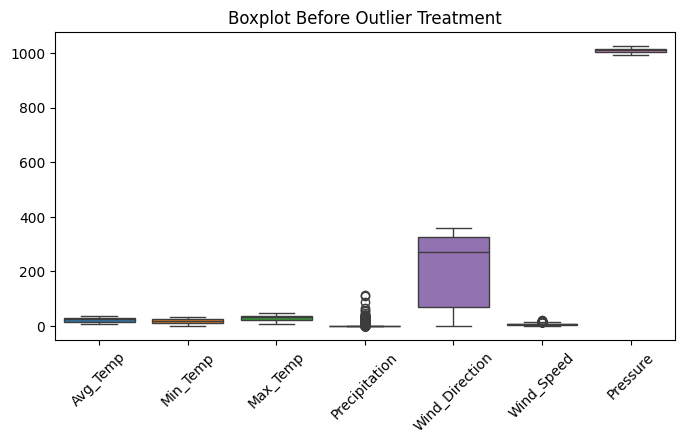

In [24]:
# Step 1: Identify numerical columns and ensure they exist in the dataframe
num_cols = df.select_dtypes(include=['number']).columns
num_cols = [col for col in num_cols if col in df.columns]

# Step 2: Visualize the dataset before outlier treatment
plt.figure(figsize=(8, 4))
sns.boxplot(data=df[num_cols])
plt.title("Boxplot Before Outlier Treatment")
plt.xticks(rotation=45)
plt.show()


In [25]:
# Function to detect outliers using IQR method
def detect_outliers(df, columns):
    outlier_count = 0  # Initialize outlier counter

    for col in columns:
        Q1 = df[col].quantile(0.25)  # First quartile (25th percentile)
        Q3 = df[col].quantile(0.75)  # Third quartile (75th percentile)
        IQR = Q3 - Q1  # Interquartile range
        lower_bound = Q1 - 1.5 * IQR  # Lower bound for outliers
        upper_bound = Q3 + 1.5 * IQR  # Upper bound for outliers

        # Identify outliers
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_count += len(outliers)

    # Print results
    if outlier_count > 0:
        print(" ")
        print(f"⚠️ Warning: {outlier_count} outliers detected in the dataset.")
        return True  # Outliers are present
    else:
        print(" ")
        print("✅ No outliers detected in the dataset.")
        return False  # No outliers present

# Function to treat outliers using IQR method
def treat_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        if col in ["Precipitation", "Wind_Speed"]:
            # ✅ Precipitation and Wind Speed outliers are capped (values above the upper bound are set to the upper bound).
            # Why? Heavy rainfall and high wind speeds are rare but crucial for weather prediction. Removing them may lead to loss of valuable data affecting model accuracy.
            df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
        else:
            # ✅ Outliers in other columns are removed to ensure data consistency.
            df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

    return df

# Select numerical columns for outlier detection
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Step 2: Detect outliers before treatment
if detect_outliers(df, num_cols):
    print("📌 Treating outliers...")
    df = treat_outliers(df, num_cols)  # Apply treatment
    print("✅ Outliers treated successfully!")
    print(" ")


 
⚠️ Warning: 329 outliers detected in the dataset.
📌 Treating outliers...
✅ Outliers treated successfully!
 


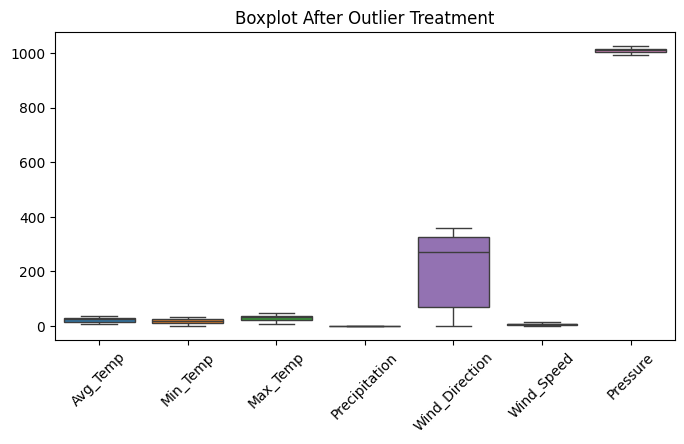

In [26]:
# Step 3: Visualize the dataset **after** outlier treatment
plt.figure(figsize=(8, 4))
sns.boxplot(data=df[num_cols])
plt.title("Boxplot After Outlier Treatment")
plt.xticks(rotation=45)
plt.show()


# **✅ Feature Engineering**

In [27]:
# Create a copy of the original dataset with new features
df_weather_enhanced = df.copy()

In [28]:
# Create a new feature for temperature variation
df_weather_enhanced['Temp_Variation'] = df_weather_enhanced['Max_Temp'] - df_weather_enhanced['Min_Temp']

In [29]:
# Convert wind direction into four main categories: North, East, South, West
df_weather_enhanced['Wind_Direction_Label'] = pd.cut(
    df_weather_enhanced['Wind_Direction'],
    bins=[0, 90, 180, 270, 360],
    labels=['North', 'East', 'South', 'West'],
    include_lowest=True
)

In [30]:
# Create a binary feature indicating if precipitation occurred
df_weather_enhanced['Rainfall_YesNo'] = (df_weather_enhanced['Precipitation'] > 0).astype(int)

# Display the first 10 rows of the updated dataset
df_weather_enhanced.head(5)

,Avg_Temp,Min_Temp,Max_Temp,Precipitation,Wind_Direction,Wind_Speed,Pressure,Temp_Variation,Wind_Direction_Label,Rainfall_YesNo
Date,,,,,,,,,,
2021-01-01,6.4,2.2,13.7,0.0,0.0,0.0,1018.3,11.5,North,0
2021-01-02,9.9,2.6,14.0,1.0,2.0,0.2,1017.9,11.4,North,1
2021-01-03,14.3,11.3,18.0,1.0,35.0,4.1,1015.0,6.7,North,1
2021-01-04,16.4,11.0,19.2,1.0,39.0,5.2,1016.7,8.2,North,1
2021-01-05,15.6,13.0,19.9,1.0,23.0,2.1,1015.8,6.9,North,1


# **✅ Feature Selection**

In [31]:
# Selecting relevant features based on today's weather to predict rainfall
features = ['Avg_Temp', 'Min_Temp', 'Max_Temp', 'Wind_Direction', 'Wind_Speed',
            'Pressure', 'Temp_Variation']
target = 'Rainfall_YesNo'  # Our target: 1 if it rained, 0 if not

# **✅ Data Visualization**

## Rainfall Distribution

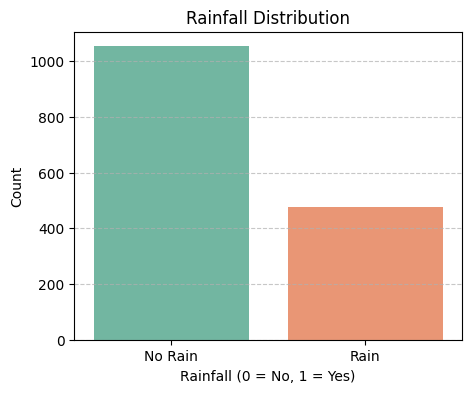

In [32]:
# Countplot to show distribution of Rainfall (0 = No Rain, 1 = Yes)
plt.figure(figsize=(5, 4))
sns.countplot(x='Rainfall_YesNo', hue='Rainfall_YesNo', data=df_weather_enhanced, palette='Set2', legend=False)
plt.title("Rainfall Distribution")
plt.xlabel("Rainfall (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.xticks([0, 1], ['No Rain', 'Rain'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## Feature Distributions

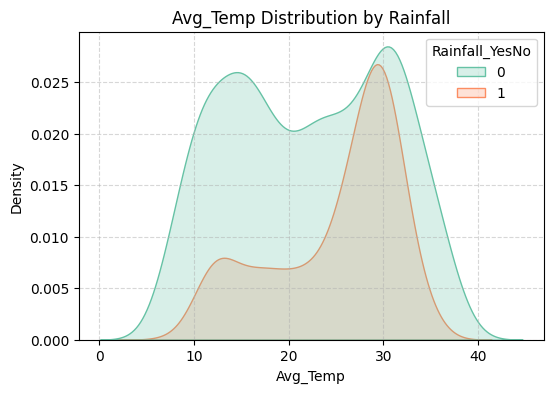

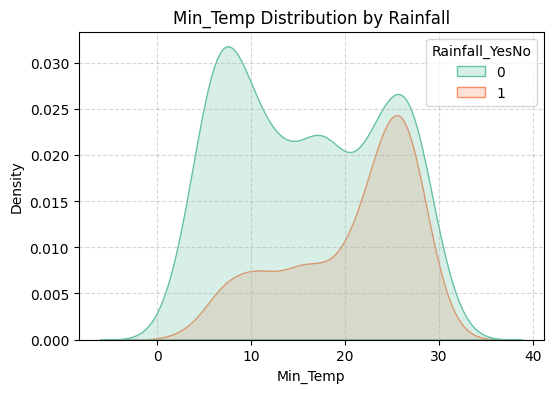

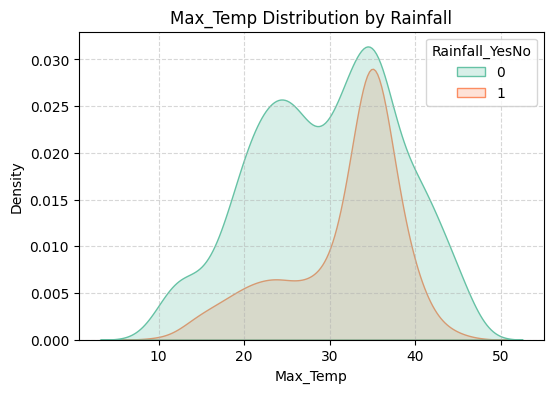

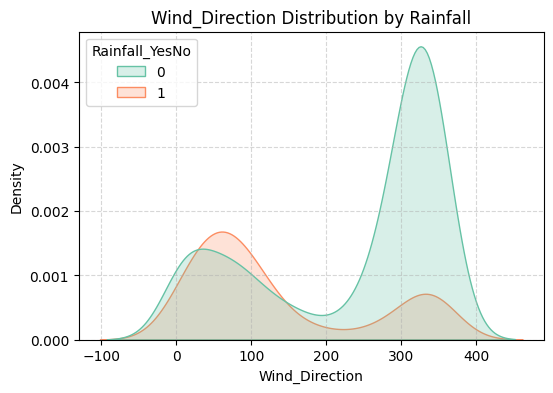

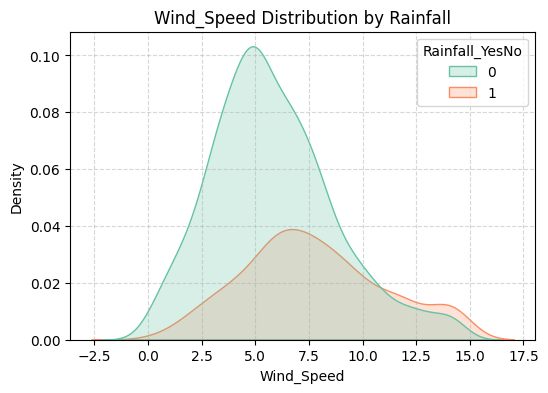

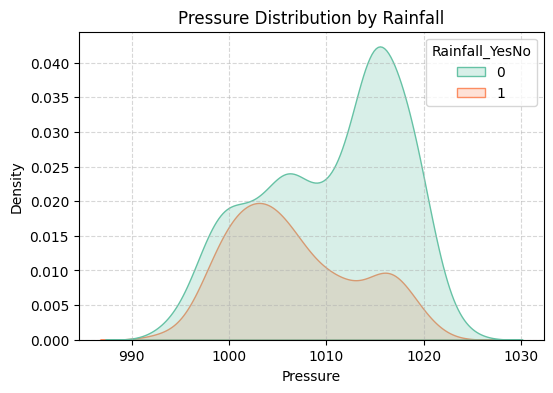

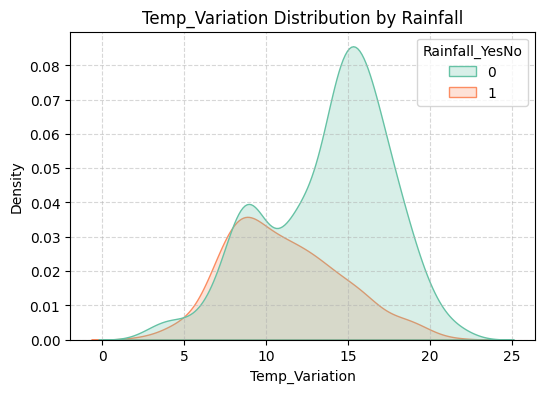

In [33]:
# Distribution plots for each feature grouped by Rainfall
for col in features:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(data=df_weather_enhanced, x=col, hue='Rainfall_YesNo', fill=True, palette='Set2')
    plt.title(f"{col} Distribution by Rainfall")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()


## Correlation Heatmap

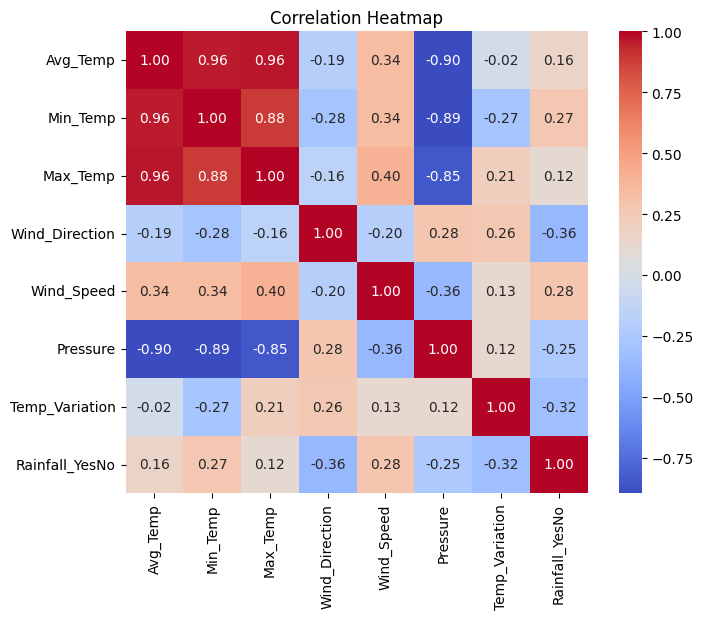

In [34]:
# Calculate correlation matrix
correlation_matrix = df_weather_enhanced[features + [target]].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Correlation Heatmap")
plt.show()


# **✅ Model Building for Rainfall Prediction**

In [35]:
# Splitting features (X) and target variable (y)
X = df_weather_enhanced[features]
y = df_weather_enhanced[target]

In [36]:
# Train-Test Split
from sklearn.model_selection import train_test_split

# Splitting dataset into 80% training and 20% testing to evaluate model performance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # Ensures class balance in split
)

In [37]:
#  Model Training - Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize Logistic Regression model
lr = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [38]:
#  Predictions
y_pred = lr.predict(X_test)

In [39]:
#  Evaluation
print("🔍 Accuracy Score:", accuracy_score(y_test, y_pred))
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))
print("\n🧩 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

🔍 Accuracy Score: 0.7745098039215687

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.90      0.85       211
           1       0.69      0.51      0.58        95

    accuracy                           0.77       306
   macro avg       0.74      0.70      0.71       306
weighted avg       0.77      0.77      0.76       306


🧩 Confusion Matrix:
 [[189  22]
 [ 47  48]]


In [ ]:
# Ask user for inputs
print("🌦️ Weather Input Form to Predict Rain:\n")

avg_temp = float(input("Average Temperature (°C): "))
min_temp = float(input("Minimum Temperature (°C): "))
max_temp = float(input("Maximum Temperature (°C): "))
wind_dir = float(input("Wind Direction (°): "))
wind_speed = float(input("Wind Speed (km/h): "))
pressure = float(input("Atmospheric Pressure (hPa): "))
temp_variation = float(input("Temperature Variation (°C): "))

# Create DataFrame with input
user_input = pd.DataFrame([{
    'Avg_Temp': avg_temp,
    'Min_Temp': min_temp,
    'Max_Temp': max_temp,
    'Wind_Direction': wind_dir,
    'Wind_Speed': wind_speed,
    'Pressure': pressure,
    'Temp_Variation': temp_variation
}])

# Predict using trained model
prediction = lr.predict(user_input)[0]

# Output result
print("\n🌧️ Prediction: It WILL rain today!" if prediction == 1 else "\n☀️ Prediction: It will NOT rain today.")


🌦️ Weather Input Form to Predict Rain:

